<a href="https://colab.research.google.com/github/leesasang/codein_study/blob/main/%EC%A3%BC%EC%8B%9D%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

데이터 앞부분
                                   Open          High           Low  \
Date                                                                  
2020-01-02 00:00:00+09:00  47728.896378  48158.886436  47298.906321   
2020-01-03 00:00:00+09:00  48158.884572  48674.872621  47212.906482   
2020-01-06 00:00:00+09:00  47212.906482  47814.892539  46954.912458   
2020-01-07 00:00:00+09:00  47900.884815  48502.870800  47814.886817   
2020-01-08 00:00:00+09:00  48330.886884  49362.863116  48072.892826   

                                  Close    Volume  Dividends  Stock Splits  
Date                                                                        
2020-01-02 00:00:00+09:00  47470.902344  12993228        0.0           0.0  
2020-01-03 00:00:00+09:00  47728.894531  15422255        0.0           0.0  
2020-01-06 00:00:00+09:00  47728.894531  10278951        0.0           0.0  
2020-01-07 00:00:00+09:00  47986.882812  10009778        0.0           0.0  
2020-01-08 00:00:00+09:00  48846

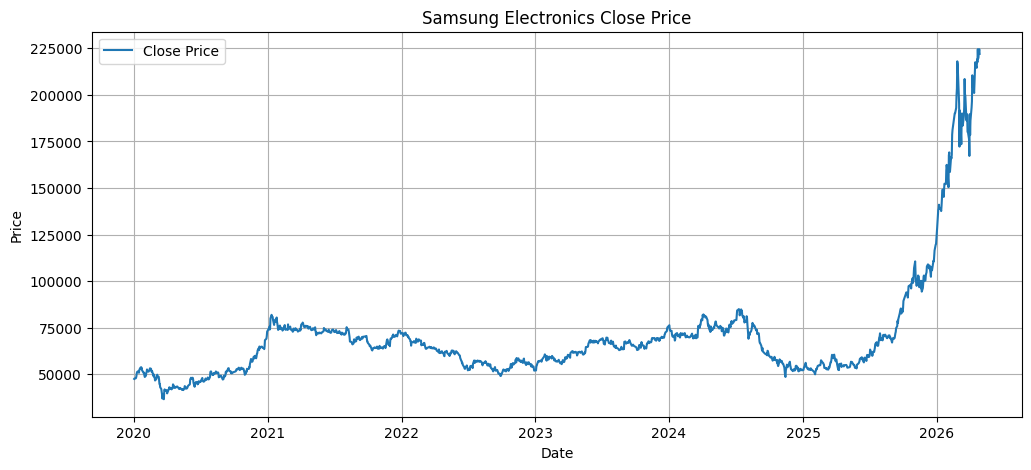

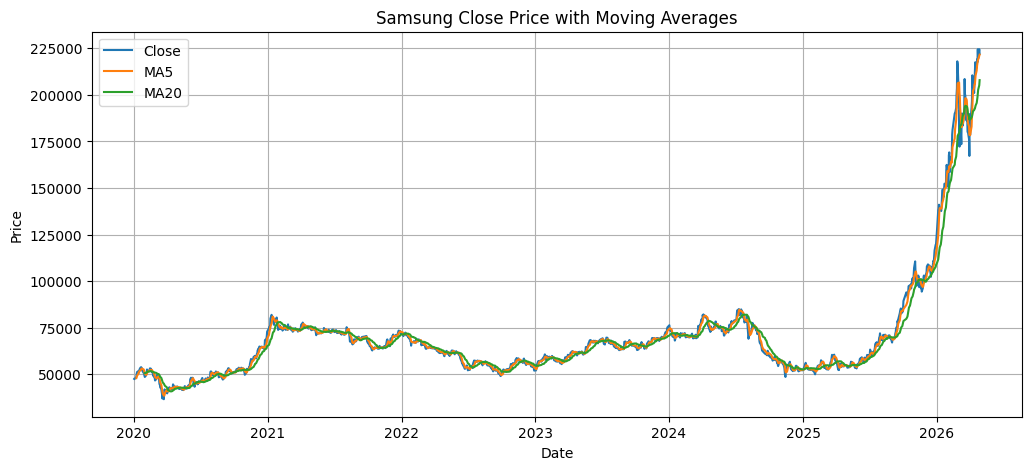


예측용 데이터
                                   Open          High           Low  \
Date                                                                  
2020-01-31 00:00:00+09:00  49706.835065  50222.822972  48502.863281   
2020-02-03 00:00:00+09:00  47728.885694  49362.847547  47470.891718   
2020-02-04 00:00:00+09:00  49104.860151  50738.822223  48846.866140   
2020-02-05 00:00:00+09:00  51598.806460  51770.802482  50652.828342   
2020-02-06 00:00:00+09:00  51684.808881  52544.789062  51340.816809   

                                  Close    Volume           MA5          MA20  \
Date                                                                            
2020-01-31 00:00:00+09:00  48502.863281  19749457  50274.435156  50579.728711   
2020-02-03 00:00:00+09:00  49190.851562  23995260  49655.244531  50665.726172   
2020-02-04 00:00:00+09:00  50652.824219  21800192  49672.444531  50811.922656   
2020-02-05 00:00:00+09:00  51168.816406  19278165  49741.241406  50983.918750   
2020-02

In [1]:
# 필요한 라이브러리 설치
# !pip install yfinance scikit-learn

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# 1. 삼성전자 데이터 불러오기
samsung = yf.Ticker("005930.KS").history(start="2020-01-01")

# 데이터 확인
print("데이터 앞부분")
print(samsung.head())

print("\n데이터 뒷부분")
print(samsung.tail())


# 2. 결측치, 기간 확인
print("\n결측치 확인")
print(samsung.isnull().sum())

print("\n데이터 기간")
print("시작일:", samsung.index.min())
print("종료일:", samsung.index.max())

print("\n데이터 크기:", samsung.shape)


# 3. 종가 흐름 시각화
plt.figure(figsize=(12, 5))
plt.plot(samsung.index, samsung["Close"], label="Close Price")
plt.title("Samsung Electronics Close Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()


# 4. 5일, 20일 이동평균선 만들기
samsung["MA5"] = samsung["Close"].rolling(window=5).mean()
samsung["MA20"] = samsung["Close"].rolling(window=20).mean()

plt.figure(figsize=(12, 5))
plt.plot(samsung.index, samsung["Close"], label="Close")
plt.plot(samsung.index, samsung["MA5"], label="MA5")
plt.plot(samsung.index, samsung["MA20"], label="MA20")
plt.title("Samsung Close Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()


# 5. 예측용 데이터 만들기
# 오늘의 정보로 내일 종가를 예측하기 위해 Close를 하루 뒤로 밀어서 Target 생성
samsung["Tomorrow_Close"] = samsung["Close"].shift(-1)

# 예측에 사용할 변수
features = ["Open", "High", "Low", "Close", "Volume", "MA5", "MA20"]

# 결측치 제거
data = samsung[features + ["Tomorrow_Close"]].dropna()

X = data[features]
y = data["Tomorrow_Close"]

print("\n예측용 데이터")
print(data.head())


# 6. 선형회귀 모델 사용
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

model = LinearRegression()
model.fit(X_train, y_train)

# 테스트 데이터 예측
y_pred = model.predict(X_test)

print("\n모델 평가")
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


# 내일 종가 예측
latest_data = samsung[features].dropna().iloc[-1:]
tomorrow_prediction = model.predict(latest_data)

print("\n가장 최근 데이터")
print(latest_data)

print("\n삼성전자 내일 종가 예측값")
print(f"{tomorrow_prediction[0]:,.0f}원")